In [1]:
import os
import pandas as pd

# Preparing the dataset

In [2]:
damaged_images_path = "/kaggle/input/damaged-and-intact-packages/damaged-and-intact-packages/damaged"
intact_images_path = "/kaggle/input/damaged-and-intact-packages/damaged-and-intact-packages/intact"

In [3]:
# get the filepaths of images of damaged and intact packages
damaged = []
intact = []

for image in os.listdir(damaged_images_path):
    damaged.append((os.path.join(damaged_images_path, image), 1))

for image in os.listdir(intact_images_path):
    intact.append((os.path.join(intact_images_path, image), 0))

In [4]:
len(damaged), len(intact)

(286, 342)

In [5]:
damaged_df = pd.DataFrame(damaged, columns = ['img_path', 'class'])
damaged_df['class'] = damaged_df['class'].astype('str')

intact_df = pd.DataFrame(intact, columns = ['img_path', 'class'])
intact_df['class'] = intact_df['class'].astype('str')

In [6]:
# split the damaged and intact images into train, validation and test images
from sklearn.model_selection import train_test_split

damaged_train_df, damaged_val_df = train_test_split(damaged_df, test_size=0.3, random_state=7)
damaged_val_df, damaged_test_df = train_test_split(damaged_val_df, test_size=0.5, random_state=7)

intact_train_df, intact_val_df = train_test_split(intact_df, test_size=0.3, random_state=7)
intact_val_df, intact_test_df = train_test_split(intact_val_df, test_size=0.5, random_state=7)

In [7]:
# create the final dataset for train, validation and test that contains both damaged and intact images in equal proportions
train_df = pd.concat([damaged_train_df, intact_train_df])
val_df = pd.concat([damaged_val_df, intact_val_df])
test_df = pd.concat([damaged_test_df, intact_test_df])

# shuffle the dataset
train_df = train_df.sample(frac = 1)
val_df = val_df.sample(frac = 1)
test_df = test_df.sample(frac = 1)

In [8]:
train_df.head()

,img_path,class
116,/kaggle/input/damaged-and-intact-packages/dama...,0
277,/kaggle/input/damaged-and-intact-packages/dama...,1
260,/kaggle/input/damaged-and-intact-packages/dama...,0
94,/kaggle/input/damaged-and-intact-packages/dama...,0
19,/kaggle/input/damaged-and-intact-packages/dama...,0


In [9]:
train_df['class'].value_counts()

0    239
1    200
Name: class, dtype: int64

In [10]:
test_df['class'].value_counts()

0    52
1    43
Name: class, dtype: int64

In [11]:
val_df['class'].value_counts()

0    51
1    43
Name: class, dtype: int64

In [12]:
len(train_df), len(val_df), len(test_df)

(439, 94, 95)

In [13]:
import tensorflow as tf

In [14]:
img_width = 256
img_height = 256
n_channels = 1
batch_size = 16
class_names = ['intact', 'damaged']
num_classes = 2

In [15]:
# data generator for training dataset, performs data augmentations
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True
)

# data generator for validation and testing dataset, here no data augmentation is performed
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

In [16]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'img_path',
    y_col = 'class',
    target_size = (img_width, img_height),
    color_mode = 'rgb',
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True,
    seed = 7
)

valid_generator = val_test_datagen.flow_from_dataframe(
    dataframe = val_df,
    x_col = 'img_path',
    y_col = 'class',
    target_size = (img_width, img_height),
    color_mode = 'rgb',
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True,
    seed = 7
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'img_path',
    y_col = 'class',
    target_size = (img_width, img_height),
    color_mode = 'rgb',
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True,
    seed = 7
)

Found 408 validated image filenames belonging to 2 classes.
Found 86 validated image filenames belonging to 2 classes.


/opt/conda/lib/python3.7/site-packages/keras/preprocessing/image.py:1139: UserWarning: Found 31 invalid image filename(s) in x_col="img_path". These filename(s) will be ignored.
  "These filename(s) will be ignored.".format(n_invalid, x_col)
/opt/conda/lib/python3.7/site-packages/keras/preprocessing/image.py:1139: UserWarning: Found 8 invalid image filename(s) in x_col="img_path". These filename(s) will be ignored.
  "These filename(s) will be ignored.".format(n_invalid, x_col)


Found 88 validated image filenames belonging to 2 classes.


/opt/conda/lib/python3.7/site-packages/keras/preprocessing/image.py:1139: UserWarning: Found 7 invalid image filename(s) in x_col="img_path". These filename(s) will be ignored.
  "These filename(s) will be ignored.".format(n_invalid, x_col)


In [17]:
import os

def create_model_checkpoint(model_name, save_path="model_checkpoints"):
  return tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(save_path, model_name),
    verbose=0,
    save_best_only=True,
    monitor = 'val_accuracy'
  )

# Building a model with ResNet-34 Architecture

![ResNet-32 Architecture](https://editor.analyticsvidhya.com/uploads/38371XTo6Q.png)

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def identity_block(x, filter):
    # copy tensor to variable called x_skip
    x_skip = x
    # Layer 1
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    x = tf.keras.layers.Activation('relu')(x)
    # Layer 2
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    # Add Residue
    x = tf.keras.layers.Add()([x, x_skip])     
    x = tf.keras.layers.Activation('relu')(x)
    return x

In [20]:
def convolutional_block(x, filter):
    # copy tensor to variable called x_skip
    x_skip = x
    # Layer 1
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same', strides = (2,2))(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    x = tf.keras.layers.Activation('relu')(x)
    # Layer 2
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    # Processing Residue with conv(1,1)
    x_skip = tf.keras.layers.Conv2D(filter, (1,1), strides = (2,2))(x_skip)
    # Add Residue
    x = tf.keras.layers.Add()([x, x_skip])     
    x = tf.keras.layers.Activation('relu')(x)
    return x

In [21]:
def ResNet34(shape = (32, 32, 3), classes = 10):
    # Step 1 (Setup Input Layer)
    x_input = tf.keras.layers.Input(shape)
    x = tf.keras.layers.ZeroPadding2D((3, 3))(x_input)
    # Step 2 (Initial Conv layer along with maxPool)
    x = tf.keras.layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding='same')(x)
    # Define size of sub-blocks and initial filter size
    block_layers = [3, 4, 6, 3]
    filter_size = 64
    # Step 3 Add the Resnet Blocks
    for i in range(4):
        if i == 0:
            # For sub-block 1 Residual/Convolutional block not needed
            for j in range(block_layers[i]):
                x = identity_block(x, filter_size)
        else:
            # One Residual/Convolutional Block followed by Identity blocks
            # The filter size will go on increasing by a factor of 2
            filter_size = filter_size*2
            x = convolutional_block(x, filter_size)
            for j in range(block_layers[i] - 1):
                x = identity_block(x, filter_size)
    # Step 4 End Dense Network
    x = tf.keras.layers.AveragePooling2D((2,2), padding = 'same')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation = 'relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(classes, activation = 'softmax')(x)
    model = tf.keras.models.Model(inputs = x_input, outputs = x, name = "ResNet34")
    return model

In [22]:
resnet34_model = ResNet34(shape = (img_width, img_height, 3), classes = 2)

In [23]:
resnet34_model.summary()

Model: "ResNet34"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 262, 262, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 131, 131, 64  9472        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                           

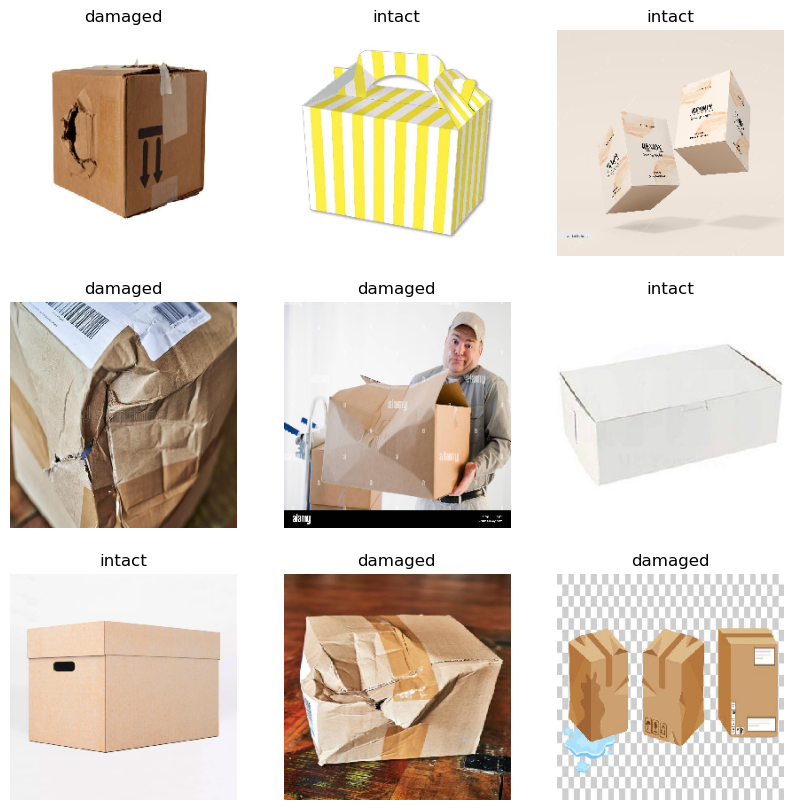

In [24]:
val_iter = iter(valid_generator)
batch = next(val_iter)

images, labels = batch

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

In [25]:
resnet34_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = resnet34_model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = 300,
    callbacks = [create_model_checkpoint(model_name='resnet34_model.h5')]
)

Epoch 1/300


/opt/conda/lib/python3.7/site-packages/PIL/Image.py:980: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


26/26 [==============================] - 42s 536ms/step - loss: 7.9504 - accuracy: 0.4902 - val_loss: 489336416.0000 - val_accuracy: 0.5341
Epoch 2/300
26/26 [==============================] - 11s 405ms/step - loss: 2.8447 - accuracy: 0.6078 - val_loss: 426153.7188 - val_accuracy: 0.5341
Epoch 3/300
26/26 [==============================] - 12s 438ms/step - loss: 1.6589 - accuracy: 0.6397 - val_loss: 115149.2422 - val_accuracy: 0.5455
Epoch 4/300
26/26 [==============================] - 12s 442ms/step - loss: 2.6110 - accuracy: 0.5123 - val_loss: 31.2819 - val_accuracy: 0.6477
Epoch 5/300
26/26 [==============================] - 11s 405ms/step - loss: 1.1640 - accuracy: 0.6569 - val_loss: 0.9627 - val_accuracy: 0.4659
Epoch 6/300
26/26 [==============================] - 11s 405ms/step - loss: 0.9104 - accuracy: 0.6152 - val_loss: 0.7888 - val_accuracy: 0.4659
Epoch 7/300
26/26 [==============================] - 11s 404ms/step - loss: 0.7558 - accuracy: 0.6667 - val_loss: 0.7571 - val_ac

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

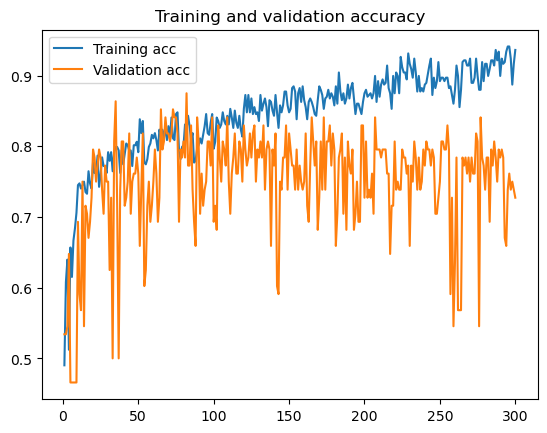

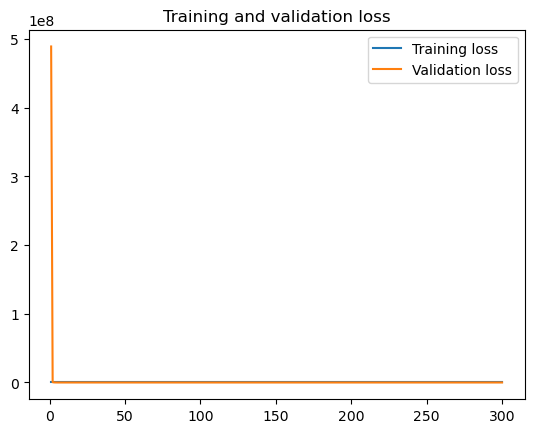

In [27]:
import matplotlib.pyplot as plt

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [28]:
# %env KAGGLE_USERNAME=rahulm7323
# %env KAGGLE_KEY=009ff5c8784ddc129f28cdf5a93ee2a2

In [29]:
# !kaggle kernels output rahulm7323/damaged-package-detection -p /kaggle/working/background-output/

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# load the best model
# resnet34_model_best = tf.keras.models.load_model('/kaggle/working/background-output/model_checkpoints/resnet34_model.h5')

resnet34_model_best = tf.keras.models.load_model('/kaggle/working/model_checkpoints/resnet34_model.h5')

In [31]:
resnet34_model_best.evaluate(valid_generator)

6/6 [==============================] - 2s 317ms/step - loss: 0.4446 - accuracy: 0.7907


[0.4446008801460266, 0.7906976938247681]

In [32]:
resnet34_model_best.evaluate(test_generator)

6/6 [==============================] - 1s 202ms/step - loss: 0.6050 - accuracy: 0.8750


[0.604951798915863, 0.875]

In [33]:
# get the convolutional layers
conv_layers = []

for layer in resnet34_model_best.layers:
    if 'conv' in layer.name:
        filters, biases = layer.get_weights()
        conv_layers.append(layer)
        print(layer.name, filters.shape)

conv2d (7, 7, 3, 64)
conv2d_1 (3, 3, 64, 64)
conv2d_2 (3, 3, 64, 64)
conv2d_3 (3, 3, 64, 64)
conv2d_4 (3, 3, 64, 64)
conv2d_5 (3, 3, 64, 64)
conv2d_6 (3, 3, 64, 64)
conv2d_7 (3, 3, 64, 128)
conv2d_8 (3, 3, 128, 128)
conv2d_9 (1, 1, 64, 128)
conv2d_10 (3, 3, 128, 128)
conv2d_11 (3, 3, 128, 128)
conv2d_12 (3, 3, 128, 128)
conv2d_13 (3, 3, 128, 128)
conv2d_14 (3, 3, 128, 128)
conv2d_15 (3, 3, 128, 128)
conv2d_16 (3, 3, 128, 256)
conv2d_17 (3, 3, 256, 256)
conv2d_18 (1, 1, 128, 256)
conv2d_19 (3, 3, 256, 256)
conv2d_20 (3, 3, 256, 256)
conv2d_21 (3, 3, 256, 256)
conv2d_22 (3, 3, 256, 256)
conv2d_23 (3, 3, 256, 256)
conv2d_24 (3, 3, 256, 256)
conv2d_25 (3, 3, 256, 256)
conv2d_26 (3, 3, 256, 256)
conv2d_27 (3, 3, 256, 256)
conv2d_28 (3, 3, 256, 256)
conv2d_29 (3, 3, 256, 512)
conv2d_30 (3, 3, 512, 512)
conv2d_31 (1, 1, 256, 512)
conv2d_32 (3, 3, 512, 512)
conv2d_33 (3, 3, 512, 512)
conv2d_34 (3, 3, 512, 512)
conv2d_35 (3, 3, 512, 512)


In [34]:
filters, biases = conv_layers[0].get_weights()

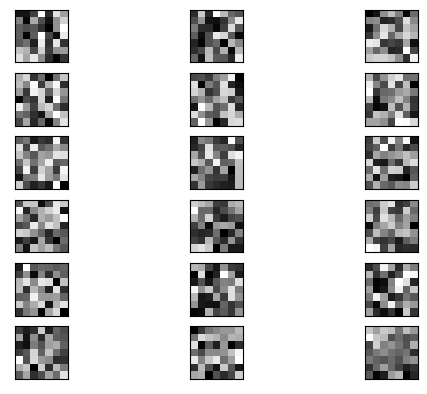

In [35]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
# plot first few filters
n_filters, ix = 6, 1
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # plot each channel separately
    for j in range(3):
        # specify subplot and turn of axis
        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1
# show the figure
plt.show()

In [36]:
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.models import Model
from matplotlib import pyplot
from numpy import expand_dims

In [37]:
def visualize_feature_map(img, level):
    img = img_to_array(img)
    img = expand_dims(img, axis=0)
    img = img/255
    
    model = Model(inputs=resnet34_model_best.inputs, outputs=conv_layers[level].output)
    feature_maps = model.predict(img)

    square = 2
    ix = 1
    for _ in range(square):
        for _ in range(square):
            ax = pyplot.subplot(square, square, ix)
            ax.set_xticks([])
            ax.set_yticks([])

            pyplot.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
            ix += 1

    # show the figure
    pyplot.show()

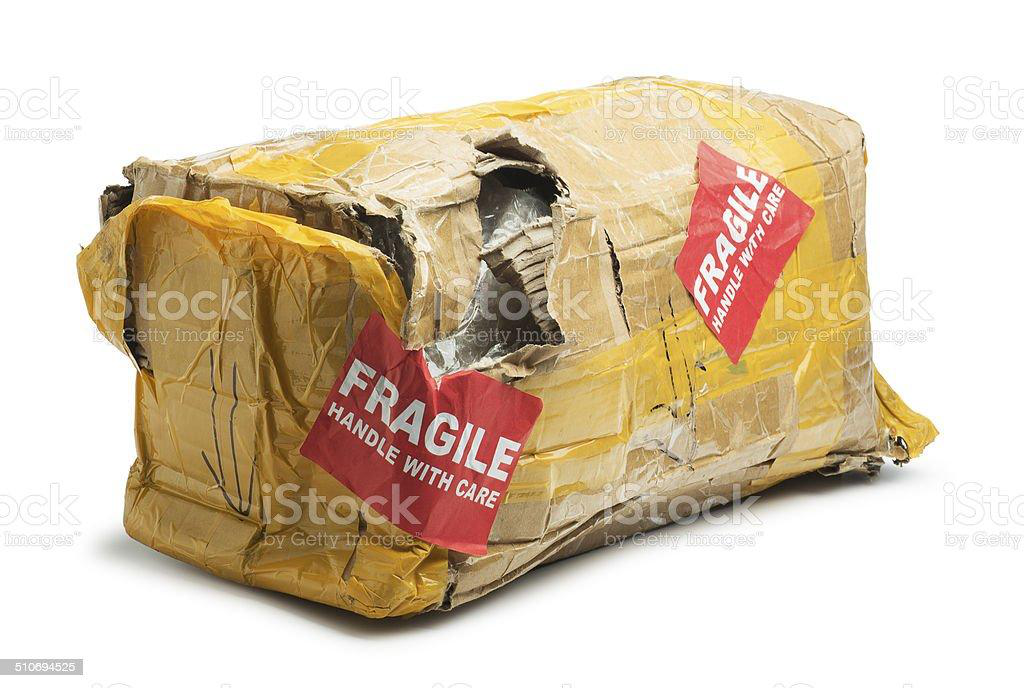

In [38]:
from PIL import Image

Image.open(damaged_images_path + '/damagedfoodpackagingbox10.jpeg')

1/1 [==============================] - 0s 221ms/step


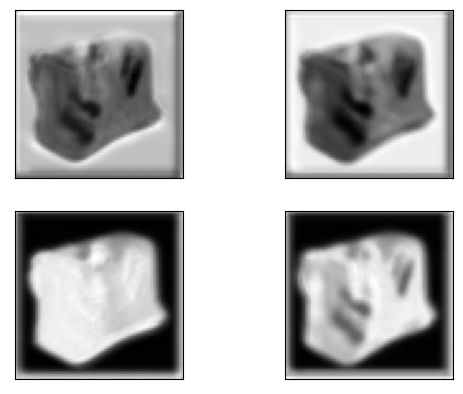

In [39]:
img_damaged = load_img(damaged_images_path + '/damagedfoodpackagingbox10.jpeg', target_size=(img_width, img_height))

visualize_feature_map(img_damaged, 5)

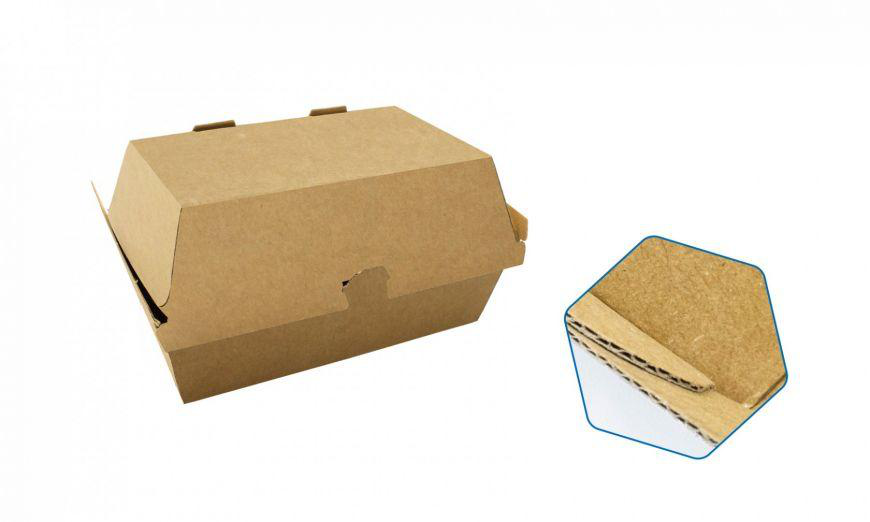

In [40]:
Image.open(intact_images_path + '/fooditemboxes174.jpeg')

1/1 [==============================] - 0s 112ms/step


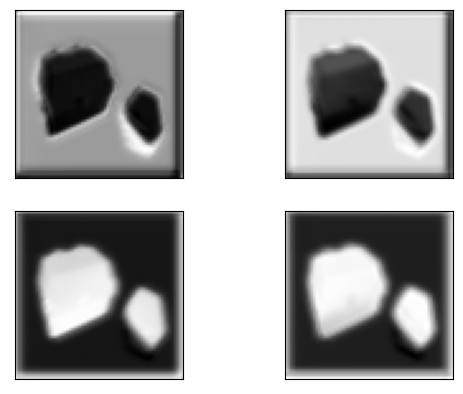

In [41]:
img_intact = load_img(intact_images_path + '/fooditemboxes174.jpeg', target_size=(img_width, img_height))

visualize_feature_map(img_intact, 5)

In [42]:
x = tf.convert_to_tensor(img_damaged)
x = np.expand_dims(x, axis=0)
x = x/255

resnet34_model_best.predict(x)

1/1 [==============================] - 1s 776ms/step


array([[0.28340414, 0.7165959 ]], dtype=float32)

In [43]:
x = tf.convert_to_tensor(img_intact)
x = np.expand_dims(x, axis=0)
x = x/255

resnet34_model_best.predict(x)

1/1 [==============================] - 0s 25ms/step


array([[0.4731325 , 0.52686745]], dtype=float32)